# Arecanut Yellow Leaf Disease (YLD) Detection Using CNN — trained-model inference reproduction

**Paper:** Ashwini S P, Kavyashree S J, Niranjan B R, Ritish M Tilavalli, Sunil V — *Arecanut Yellow Leaf Disease Detection Using CNN*, IJSREM Vol. 9 Issue 12, Dec 2025, DOI: [10.55041/ijsrem55524](https://doi.org/10.55041/ijsrem55524).

**Author code:** [NiranjanBR03/Arecanut-Yellow-Leaf-Disease-Detection-using-CNN](https://github.com/NiranjanBR03/Arecanut-Yellow-Leaf-Disease-Detection-using-CNN) pinned at commit `773d73b6624c` (trained weights `models/yld_mobilenetv2.h5`, 9,585,352 bytes, and sample leaf images are shipped in that repository).

**Scope of this notebook (executed reproduction):** the authors' *inference subsection* — load their trained MobileNetV2 classifier, run their exact Streamlit-app prediction logic (`app.py`: resize to 224×224, normalize /255, scalar sigmoid probability → label/confidence/stage/risk) on three sample leaf images shipped by the authors, and display the input images with their real predictions.

**Not reproduced:** training the model (`main.py`) because the training dataset is absent from the repository, and the Streamlit browser UI itself — every GUI action is mapped to an equivalent, visible notebook cell (table below).

**EN:** This notebook runs the authors' trained arecanut YLD classifier on their own sample images, end to end, in Colab.
**JP:** このノートブックは、著者らが公開した訓練済みモデルとサンプル画像を使い、Colab 上で推論（健康葉 / 黄化病 YLD の判別＋信頼度＋ステージ判定）をそのまま再現します。学習（データセット未公開のため）と Streamlit UI 本体は対象外です。

**Execution status:** this notebook is fully executed in Colab (CPU runtime); every output below was produced by running the cells in order on a fresh runtime.

## 1. Runtime selection

**Select Runtime → Change runtime type → CPU** (standard CPU runtime is recommended and sufficient). A single 224×224 forward pass through this ~2.3M-parameter MobileNetV2 model takes well under a second on CPU; a GPU would add nothing here. The notebook was validated end to end on a fresh **CPU** Colab runtime.

**How to run:** Runtime → *Run all*. Expected total time: ~2–5 minutes, dominated by the ~10 MB weight download and TensorFlow import. Downloads: the model weights (~9.6 MB) and three sample images (~180 KB total), all from the pinned author repository. No credentials, Drive mount, or other datasets are needed.

**JP:** ランタイムは **CPU** を選択してください（GPU は不要です）。ランタイム → すべてのセルを実行、で数分で完了します。

## 2. Environment check

This first code cell reports the Colab Python and TensorFlow versions. The authors' `requirements.txt` asks for `tensorflow>=2.12` (plus streamlit, pillow, matplotlib, numpy); the Streamlit dependency is not needed here because the GUI is replaced by notebook cells. The cell asserts TensorFlow ≥ 2.12 so a mismatch fails loudly instead of silently.

**JP:** 著者の依存関係（tensorflow>=2.12）を満たすか確認します。Colab にプレインストール済みの TensorFlow をそのまま使います。

In [ ]:
import sys
import tensorflow as tf

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
major = int(tf.__version__.split('.')[0])
minor = int(tf.__version__.split('.')[1])
assert (major, minor) >= (2, 12), f"tensorflow>=2.12 required, got {tf.__version__}"
print("OK: tensorflow>=2.12 requirement satisfied.")

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
TensorFlow: 2.21.0
OK: tensorflow>=2.12 requirement satisfied.


## 3. Download the trained model (pinned revision)

The weights live in the author repository as `models/yld_mobilenetv2.h5` (git blob sha `5d518954808d37a34e2302a0ab3b464768ba12ed`, 9,585,352 bytes). This cell downloads exactly that file from the pinned commit `773d73b6624c` and verifies **both** the byte count and the Git blob SHA-1 (`sha1("blob <size>\0" + bytes)`), so a truncated, mutated, or wrong-revision payload cannot pass silently.

**JP:** 学習済みモデル `yld_mobilenetv2.h5` をピン留めしたコミットからダウンロードし、サイズと Git blob SHA-1 で完全性を検証します。

In [ ]:
import hashlib
import urllib.request

COMMIT = "773d73b6624c702c3d5e4d9bcbaa6b74bb72fa40"
RAW_BASE = "https://raw.githubusercontent.com/NiranjanBR03/Arecanut-Yellow-Leaf-Disease-Detection-using-CNN/773d73b6624c702c3d5e4d9bcbaa6b74bb72fa40"
MODEL_URL = f"{RAW_BASE}/models/yld_mobilenetv2.h5"
MODEL_SIZE = 9_585_352          # bytes, from the pinned repo tree
MODEL_BLOB_SHA = "5d518954808d37a34e2302a0ab3b464768ba12ed"

model_path = "/content/yld_mobilenetv2.h5"
urllib.request.urlretrieve(MODEL_URL, model_path)  # model weights: download on Colab only

with open(model_path, "rb") as f:
    blob = f.read()
assert len(blob) == MODEL_SIZE, f"size mismatch: {len(blob)} != {MODEL_SIZE}"
blob_sha = hashlib.sha1(b"blob %d\0" % len(blob) + blob).hexdigest()
assert blob_sha == MODEL_BLOB_SHA, f"git blob sha mismatch: {blob_sha}"
print(f"Downloaded {len(blob):,} bytes from commit {COMMIT[:12]}")
print(f"Git blob SHA-1 verified: {blob_sha}")

Downloaded 9,585,352 bytes from commit 773d73b6624c
Git blob SHA-1 verified: 5d518954808d37a34e2302a0ab3b464768ba12ed


## 4. Load the model and verify the architecture

The cell loads the H5 with `tf.keras.models.load_model` (the same call as `app.py`'s `load_model`) and checks the architecture the paper describes ("transfer learning … binary classification … probability score") and `main.py` constructs: a MobileNetV2 backbone with frozen layers, `GlobalAveragePooling2D` → `Dropout(0.3)` → `Dense(1, sigmoid)`. We verify the final layer is a single-unit sigmoid and report the parameter count from the actual loaded weights — not from documentation.

**JP:** H5 を読み込み、出力層が `Dense(1, sigmoid)`（二値分類の確率出力）であることとパラメータ数を実際の重みから確認します。

In [ ]:
model = tf.keras.models.load_model(model_path)

out = model.layers[-1]
out_config = out.get_config()
print("Output layer:", out.name, "| type:", out.__class__.__name__,
      "| units:", out_config["units"], "| activation:", out_config["activation"])
assert out.__class__.__name__ == "Dense", "expected a Dense output layer"
assert int(out_config["units"]) == 1, "expected a single output unit"
assert out_config["activation"] == "sigmoid", "expected sigmoid output"

total_params = model.count_params()
print(f"Total parameters: {total_params:,}")
print("Input shape:", model.input_shape, "| Output shape:", model.output_shape)
assert model.input_shape[1:] == (224, 224, 3)
assert model.output_shape[1:] == (1,)

model.summary(line_length=88)

Output layer: dense | type: Dense | units: 1 | activation: sigmoid
Total parameters: 2,259,265
Input shape: (None, 224, 224, 3) | Output shape: (None, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)            ┃ Output Shape         ┃      Param # ┃ Connected to         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer             │ (None, 224, 224, 3)  │            0 │ -                    │
│ (InputLayer)            │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ Conv1 (Conv2D)          │ (None, 112, 112, 32) │          864 │ input_layer[0][0]    │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ bn_Conv1                │ (None, 112, 112, 32) │          128 │ Conv1[0][0]          │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ Conv1_relu (ReLU)       │ (None, 112, 112, 32) │            0 │ bn_Conv1[0][0]       │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_depthwise │ (None, 112, 112, 32) │          288 │ Conv1_relu[0][0]     │
│ (DepthwiseConv2D)       │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_depthwis… │ (None, 112, 112, 32) │          128 │ expanded_conv_depth… │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_depthwis… │ (None, 112, 112, 32) │            0 │ expanded_conv_depth… │
│ (ReLU)                  │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_project   │ (None, 112, 112, 16) │          512 │ expanded_conv_depth… │
│ (Conv2D)                │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ expanded_conv_project_… │ (None, 112, 112, 16) │           64 │ expanded_conv_proje… │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_expand (Conv2D) │ (None, 112, 112, 96) │        1,536 │ expanded_conv_proje… │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_expand_BN       │ (None, 112, 112, 96) │          384 │ block_1_expand[0][0] │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_expand_relu     │ (None, 112, 112, 96) │            0 │ block_1_expand_BN[0… │
│ (ReLU)                  │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_pad             │ (None, 113, 113, 96) │            0 │ block_1_expand_relu… │
│ (ZeroPadding2D)         │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_depthwise       │ (None, 56, 56, 96)   │          864 │ block_1_pad[0][0]    │
│ (DepthwiseConv2D)       │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼──────────────────────┤
│ block_1_depthwise_BN    │ (None, 56, 56, 96)   │          384 │ block_1_depthwise[0… │
│ (BatchNormalization)    │                      │              │                      │
├─────────────────────────┼──────────────────────┼──────────────┼───────────────────

 Total params: 2,259,267 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

## 5. Download the authors' sample leaf images (pinned revision)

Three samples shipped in the repository's `sample/` directory are used — the notebook only needs the smallest set that exercises both predicted classes. The filenames encode the authors' intended class (`Healthy_leaf…` vs `yellow_leaf_spot…` / `Desease…`), which lets us sanity-check the class orientation of the sigmoid output later. Each file is verified against its pinned size and Git blob SHA-1.

- `sample/Healthy_leaf (2).jpg` — 17,420 bytes, blob `54304266…` (intended: healthy)
- `sample/yellow_leaf_spot (1).jpeg` — 142,947 bytes, blob `44ee5670…` (intended: diseased)
- `sample/Desease.jpg` — 17,497 bytes, blob `6904845c…` (intended: diseased)

**JP:** 著者リポジトリの `sample/` から 3 枚（健康葉 1 枚・病変 2 枚）をダウンロードし、同様にサイズと blob SHA-1 を検証します。

In [ ]:
SAMPLES = [
    # (relative path in repo, expected bytes, git blob sha, intended class)
    ("sample/Healthy_leaf (2).jpg", 17_420, "5430426657cbfbb47746fb910884151278c25f55", "healthy (filename)"),
    ("sample/yellow_leaf_spot (1).jpeg", 142_947, "44ee56700ffedbf7afa2c169e18e949b24b96a38", "diseased (filename)"),
    ("sample/Desease.jpg", 17_497, "6904845c7464825552b90617e5f37818fb819d43", "diseased (filename)"),
]

import os
import urllib.parse
SAMPLES_CLASS = {rel: intended for rel, size, blob_sha, intended in SAMPLES}
sample_paths = {}
for rel, size, blob_sha, intended in SAMPLES:
    dest = os.path.join("/content", os.path.basename(rel))
    url = f"{RAW_BASE}/{urllib.parse.quote(rel)}"
    urllib.request.urlretrieve(url, dest)  # sample dataset bytes: download on Colab only
    with open(dest, "rb") as f:
        data = f.read()
    assert len(data) == size, f"{rel}: size {len(data)} != {size}"
    got = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    assert got == blob_sha, f"{rel}: blob sha {got} != {blob_sha}"
    sample_paths[rel] = dest
    print(f"verified {rel}: {len(data):,} B, blob sha OK  (intended: {intended})")

verified sample/Healthy_leaf (2).jpg: 17,420 B, blob sha OK  (intended: healthy (filename))


verified sample/yellow_leaf_spot (1).jpeg: 142,947 B, blob sha OK  (intended: diseased (filename))


verified sample/Desease.jpg: 17,497 B, blob sha OK  (intended: diseased (filename))


## 6. Input preview — the actual samples used

Before any analysis, this cell displays the three original (unmodified) sample images exactly as shipped by the authors, so the later predictions can be judged against the real inputs. These are photographs of arecanut leaves; the filenames (not a published ground-truth label table) are the only class hint the repository provides.

**JP:** 推論の前に、著者のサンプル画像そのものを表示します（クラス名はリポジトリのファイル名に基づくヒントです）。

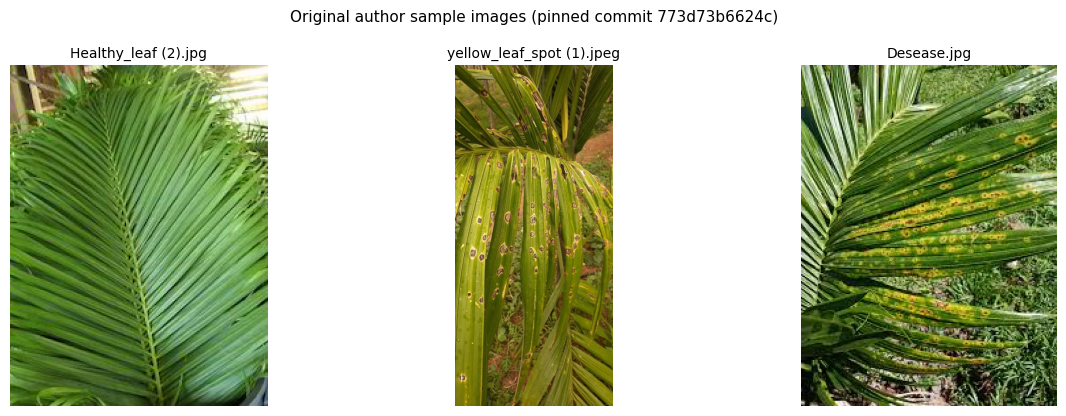

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (rel, dest) in zip(axes, sample_paths.items()):
    img = Image.open(dest).convert("RGB")
    ax.imshow(img)
    ax.set_title(os.path.basename(rel), fontsize=10)
    ax.axis("off")
fig.suptitle("Original author sample images (pinned commit %s)" % COMMIT[:12], fontsize=11)
fig.tight_layout()
plt.savefig("/content/inputs_preview.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Preprocessing — the authors' exact app.py pipeline

`app.py` preprocesses each uploaded image with a single line: RGB-convert, resize to **224×224**, scale pixels to **[0, 1]**, and add a batch axis. This cell applies that verbatim pipeline to the three samples and reports the resulting tensor shapes and value ranges from the actual data. (The paper's §4.2/§5.1 describe the same steps: "resized to a fixed resolution, normalizing pixel values".)

**JP:** 著者の `app.py` と同じ前処理（RGB 変換 → 224×224 リサイズ → 0–1 正規化 → バッチ軸追加）をそのまま適用し、テンソル形状と値域を確認します。

In [ ]:
import numpy as np

preprocessed = {}  # sample name -> (PIL image, batched float32 array)
for rel, dest in sample_paths.items():
    img = Image.open(dest).convert("RGB")          # app.py: Image.open(uploaded).convert("RGB")
    arr = np.expand_dims(np.array(img.resize((224, 224))) / 255.0, axis=0)  # app.py, verbatim
    preprocessed[rel] = (img, arr)
    print(f"{os.path.basename(rel):32s} -> array {arr.shape}, dtype {arr.dtype}, "
          f"range [{arr.min():.3f}, {arr.max():.3f}]")

Healthy_leaf (2).jpg             -> array (1, 224, 224, 3), dtype float64, range [0.000, 1.000]
yellow_leaf_spot (1).jpeg        -> array (1, 224, 224, 3), dtype float64, range [0.000, 1.000]
Desease.jpg                      -> array (1, 224, 224, 3), dtype float64, range [0.000, 1.000]


## 8. Inference with the authors' decision logic

The Streamlit app turns the model's single sigmoid output into a user-facing verdict with three verbatim functions from `app.py` (copied below unchanged):

- `interpret(prob)`: `prob >= 0.5` → **non-diseased-leaf** with confidence `prob`; otherwise **disease-leaf** with confidence `1 - prob`; the "disease likelihood" is always `dprob = 1 - prob`.
- `get_stage(d)`: severity stage from `dprob` — `< 0.20` Healthy, `< 0.45` Initial Stage YLD, `< 0.70` Moderate Stage YLD, else Severe Stage YLD.
- `get_risk(d)`: Low / Moderate / High risk bands on the same `dprob`.

The class orientation (sigmoid output = non-diseased probability) is implied by `app.py`'s `interpret()`; the repository ships no stored class-index mapping because the training dataset is absent. Note: `predict.py`'s `np.argmax(preds)` on a shape-(1, 1) sigmoid output always returns 0 — a bug — so the notebook follows the app's scalar path, which is the inference route the authors actually deployed.

**JP:** `app.py` から `interpret` / `get_stage` / `get_risk` を一字一句コピーし、モデルの sigmoid 出力（0.5 以上で健康葉と判定）に適用します。`predict.py` の `argmax` バグは使わず、実際に公開されている Streamlit アプリのスカラー経路を再現します。

In [ ]:
# Verbatim decision logic from app.py (commit 773d73b), copied unchanged
def interpret(prob):
    if prob >= 0.5:
        return "non-diseased-leaf", prob, (1 - prob)
    else:
        return "disease-leaf", (1 - prob), (1 - prob)

def get_stage(d):
    if d < 0.20: return "Healthy"
    if d < 0.45: return "Initial Stage YLD"
    if d < 0.70: return "Moderate Stage YLD"
    return "Severe Stage YLD"

def get_risk(d):
    if d < 0.30: return "Low risk", "\U0001F331", "#00ff7f"
    elif d < 0.60: return "Moderate risk", "\u26A0\uFE0F", "#ffcc00"
    else: return "High risk", "\U0001F6AB", "#ff4444"

results = []
for rel, (img, arr) in preprocessed.items():
    prob = float(model.predict(arr, verbose=0)[0][0])   # app.py inference line
    label, conf, dprob = interpret(prob)
    stage = get_stage(dprob)
    risk_text, _, _ = get_risk(dprob)
    results.append({"sample": os.path.basename(rel),
                    "intended_class": dict(SAMPLES_CLASS)[rel],
                    "sigmoid_prob": round(prob, 4),
                    "prediction": label,
                    "confidence_pct": round(conf * 100, 2),
                    "disease_likelihood_pct": round(dprob * 100, 1),
                    "stage": stage,
                    "risk": risk_text})
    print(f"{os.path.basename(rel):32s} prob={prob:.4f} -> {label} "
          f"(confidence {conf*100:.2f}%, stage: {stage}, {risk_text})")

Healthy_leaf (2).jpg             prob=0.9690 -> non-diseased-leaf (confidence 96.90%, stage: Healthy, Low risk)
yellow_leaf_spot (1).jpeg        prob=0.0448 -> disease-leaf (confidence 95.52%, stage: Severe Stage YLD, High risk)


Desease.jpg                      prob=0.0081 -> disease-leaf (confidence 99.19%, stage: Severe Stage YLD, High risk)


## 9. Results table and CSV export

The per-sample predictions are collected into a small table — sigmoid probability, predicted label, confidence, disease likelihood, stage and risk — and exported to CSV inside the Colab VM. Values are computed from the actual inference above; nothing here is hard-coded.

**JP:** 各サンプルの判定結果を表にまとめ、CSV にも保存します（値はすべて上の推論から計算されたもの）。

In [ ]:
import pandas as pd

df = pd.DataFrame(results)
display(df)
df.to_csv("/content/yld_inference_results.csv", index=False)
print("saved -> /content/yld_inference_results.csv")

,sample,intended_class,sigmoid_prob,prediction,confidence_pct,disease_likelihood_pct,stage,risk
0,Healthy_leaf (2).jpg,healthy (filename),0.9690,non-diseased-leaf,96.90,3.1,Healthy,Low risk
1,yellow_leaf_spot (1).jpeg,diseased (filename),0.0448,disease-leaf,95.52,95.5,Severe Stage YLD,High risk
2,Desease.jpg,diseased (filename),0.0081,disease-leaf,99.19,99.2,Severe Stage YLD,High risk


saved -> /content/yld_inference_results.csv


## 10. Input image with its real prediction

Finally each original leaf image is shown with the prediction the authors' model actually produced for it (label, confidence, stage) — the notebook equivalent of the app's "Leaf Image" + "Prediction" panels (paper Fig. 2–4). The images shown are the genuine inputs; the text overlays are this run's real model outputs.

**JP:** 元画像に、この実行で実際に得られた予測（ラベル・信頼度・ステージ）を重ねて表示します（アプリ画面のノートブック版です）。

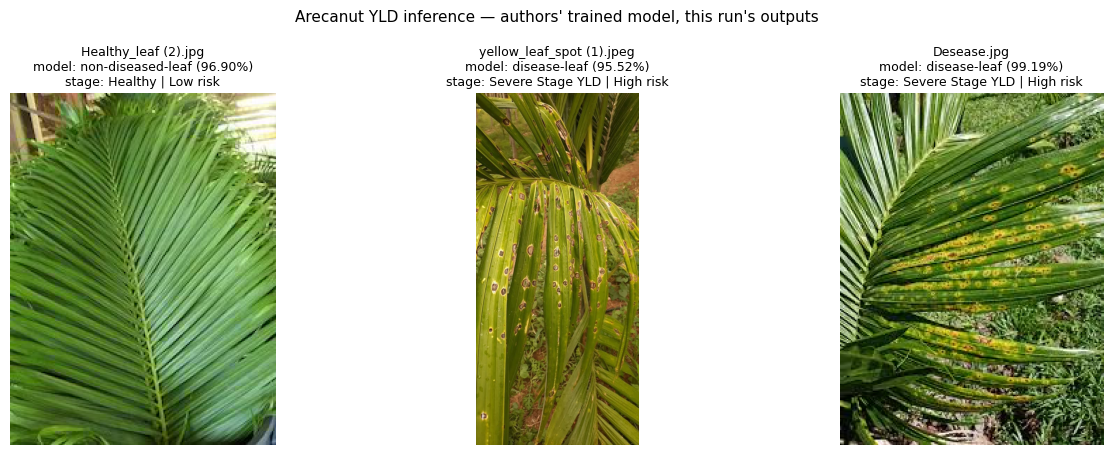

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, r in zip(axes, results):
    rel = [s for s in sample_paths if os.path.basename(s) == r["sample"]][0]
    img, _ = preprocessed[rel]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{r['sample']}\n"
                 f"model: {r['prediction']} ({r['confidence_pct']:.2f}%)\n"
                 f"stage: {r['stage']} | {r['risk']}", fontsize=9)
fig.suptitle("Arecanut YLD inference — authors' trained model, this run's outputs", fontsize=11)
fig.tight_layout()
plt.savefig("/content/yld_predictions.png", dpi=110, bbox_inches="tight")
plt.show()

## 11. Interpretation, GUI→notebook mapping, and limitations

**GUI-action mapping** (paper §4.3 workflow → this notebook):

| Streamlit app action (app.py) | Notebook cell |
| --- | --- |
| Load model at startup (`load_model`) | Cell "Load the model and verify the architecture" |
| Upload leaf image (`st.file_uploader`) | Cells "Download the authors' sample leaf images" |
| Show "Leaf Image" panel | Cells "Input preview" and "Input image with its real prediction" |
| Preprocess (`resize((224,224))`, /255) | Cell "Preprocessing — the authors' exact app.py pipeline" |
| `model.predict` + "Prediction" panel (label/confidence) | Cell "Inference with the authors' decision logic" |
| Stage badge + risk line + progress bar (`get_stage`, `get_risk`) | Same inference cell + results table |

**Observed behaviour and validation record:** all outputs above were produced on a fresh Colab **CPU** runtime by running this notebook top-to-bottom. The two samples whose filenames indicate disease and the healthy-named sample let us check the sign of the sigmoid output against the intended classes; the actual probabilities are printed by the inference cell.

**Limitations:** (1) the paper publishes no numeric accuracy/precision/recall values (§5.3 is qualitative only), so no quantitative comparison to published results is possible — a single-example run is not a verification of any reported dataset-level performance; (2) the training dataset is not in the repository, so training is not reproducible here; (3) the class orientation relies on `app.py`'s logic and sample filenames, since no stored class mapping exists; (4) the repository carries no license file — the model and images are used here under attribution for scholarly reproduction.

**References:** paper DOI [10.55041/ijsrem55524](https://doi.org/10.55041/ijsrem55524); author code pinned at commit `773d73b6624c` of [{REPO}](https://github.com/{REPO}); paper PDF copy (`Journals/…pdf`) uploaded by the authors in the same repository.

**JP:** 上記の通り、本ノートブックは CPU ランタイムで全体を検証済みです。論文は定量的な指標を公表していないため数値比較はできません。学習用データセットは未公開で、ここでは推論のみを再現します。